# 04 - Attribution analysis

> **Editor's comment.** *"Add attribution analysis - correlate snow trends with temperature,
> precipitation, and circulation indices."*

This notebook does five things, in increasing order of what a referee will accept as
*attribution* rather than *description*:

1. **Change-point detection (Pettitt test)** - an objective justification for the 2012/13
   sub-period split, which the reviewer flagged separately as arbitrary.
2. **Correlation screening** - Pearson and Spearman, on raw *and* detrended series, with
   autocorrelation-adjusted degrees of freedom and Benjamini-Hochberg FDR control.
3. **Partial correlation** - snow vs each circulation index while holding temperature and
   precipitation fixed. This separates the *dynamic* pathway from the *thermodynamic* one.
4. **Multiple regression with variance partitioning** - how much of the interannual variance
   in each snow metric is uniquely explained by temperature, by precipitation, and shared.
5. **Sensitivity coefficients and trend decomposition** - the quantitative payoff:
   *"X% of the observed snow-cover decline is attributable to warming, Y% to precipitation."*

Everything is written to `results/` as CSV plus a ready-to-paste Markdown summary.

**Honesty constraint to keep in the manuscript.** With n = 24 seasons the statistical power is
limited and this is attribution to *proximate climatic drivers*, not formal anthropogenic
detection and attribution. Say so in the Discussion; a referee will accept the limitation
stated plainly and will not accept it glossed over.

In [1]:
import os, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight", "font.size": 9})

ROOT    = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA    = os.path.join(ROOT, "data", "derived")
FIGDIR  = os.path.join(ROOT, "figures")
RESDIR  = os.path.join(ROOT, "results")
os.makedirs(FIGDIR, exist_ok=True); os.makedirs(RESDIR, exist_ok=True)

snow = pd.read_csv(os.path.join(DATA, "snow_seasonal.csv"))

def _try(name):
    p = os.path.join(DATA, name)
    if os.path.exists(p):
        print("loaded", name)
        return pd.read_csv(p)
    print("MISSING", name, "- run the notebook that creates it")
    return None

clim = _try("climate_seasonal.csv")
idx  = _try("indices_seasonal.csv")

df = snow.copy()
for extra in (clim, idx):
    if extra is not None:
        df = df.merge(extra, on="season", how="left")
df = df.sort_values("season").reset_index(drop=True)
print("merged:", df.shape)

SNOW_VARS = ["sca_mean", "sca_max", "sle_mean", "sle_djfm", "sdi_mean",
             "scv_mean", "sca_centroid", "melt_rate_feb_mar"]
SNOW_VARS = [c for c in SNOW_VARS if c in df.columns]

CLIM_VARS = [c for c in ["t2m_djfm", "t2m_ondjfm", "tmin_djfm", "tmax_djfm",
                         "precip_ondjfm", "precip_djfm", "snowfall_ondjfm",
                         "snowfall_fraction_ondjfm", "pdd_ondjfm",
                         "isotherm0_m_djfm", "swe_max"] if c in df.columns]

IDX_VARS = [c for c in df.columns
            if any(c.startswith(p) for p in
                   ["NAO_", "AO_", "EA_", "EAWR_", "SCAND_", "POL_", "WP_",
                    "NINO34_", "DMI_", "AMO_", "NCP_", "MOI_"])]
# drop predictors with too many gaps to be usable over 24 seasons
IDX_VARS = [c for c in IDX_VARS if df[c].notna().sum() >= 20]

print(f"\nsnow metrics    : {len(SNOW_VARS)}  {SNOW_VARS}")
print(f"climate drivers : {len(CLIM_VARS)}  {CLIM_VARS}")
print(f"circulation idx : {len(IDX_VARS)}")

loaded climate_seasonal.csv
loaded indices_seasonal.csv
merged: (24, 84)

snow metrics    : 8  ['sca_mean', 'sca_max', 'sle_mean', 'sle_djfm', 'sdi_mean', 'scv_mean', 'sca_centroid', 'melt_rate_feb_mar']
climate drivers : 11  ['t2m_djfm', 't2m_ondjfm', 'tmin_djfm', 'tmax_djfm', 'precip_ondjfm', 'precip_djfm', 'snowfall_ondjfm', 'snowfall_fraction_ondjfm', 'pdd_ondjfm', 'isotherm0_m_djfm', 'swe_max']
circulation idx : 36


## 1. Statistical toolbox

Small, dependency-light implementations so the notebook runs anywhere. Each one is written to
be quotable in the Methods section.

In [2]:
def sens_slope(y, x=None):
    """Theil-Sen slope + Mann-Kendall tau and p (two-sided, tie- and continuity-corrected)."""
    y = np.asarray(y, float)
    ok = np.isfinite(y)
    y = y[ok]
    x = np.arange(len(y)) if x is None else np.asarray(x, float)[ok]
    n = len(y)
    if n < 4:
        return np.nan, np.nan, np.nan
    slopes = [(y[j] - y[i]) / (x[j] - x[i])
              for i in range(n) for j in range(i + 1, n) if x[j] != x[i]]
    slope = float(np.median(slopes))
    tau, p = stats.kendalltau(x, y)
    return slope, float(tau), float(p)


def pettitt(y):
    """Pettitt (1979) change-point test. Returns (index, year-position, p-value)."""
    y = np.asarray(y, float)
    ok = np.isfinite(y)
    y = y[ok]
    n = len(y)
    r = stats.rankdata(y)
    U = np.array([2 * r[:k].sum() - k * (n + 1) for k in range(1, n + 1)])
    k = int(np.argmax(np.abs(U)))
    Kt = float(np.abs(U[k]))
    p = 2.0 * np.exp(-6.0 * Kt ** 2 / (n ** 3 + n ** 2))
    return k, min(p, 1.0), Kt


def lag1(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return 0.0
    return float(np.corrcoef(x[:-1], x[1:])[0, 1])


def eff_n(x, y):
    """Bretherton et al. (1999) effective sample size for autocorrelated series."""
    n = min(len(x), len(y))
    r1, r2 = lag1(x), lag1(y)
    denom = 1 + r1 * r2
    if denom <= 0:
        return float(n)
    return float(n * (1 - r1 * r2) / denom)


def corr_adj(x, y, method="pearson", detrend=False, adjust_df=True):
    """Correlation with optional detrending and autocorrelation-adjusted p-value."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if len(x) < 6:
        return np.nan, np.nan, len(x)
    if detrend:
        t = np.arange(len(x))
        x = x - np.polyval(np.polyfit(t, x, 1), t)
        y = y - np.polyval(np.polyfit(t, y, 1), t)
    r = (stats.pearsonr(x, y)[0] if method == "pearson"
         else stats.spearmanr(x, y)[0])
    ne = eff_n(x, y) if adjust_df else len(x)
    ne = max(ne, 4.0)
    tval = r * np.sqrt((ne - 2) / max(1e-12, 1 - r ** 2))
    p = 2 * stats.t.sf(abs(tval), df=ne - 2)
    return float(r), float(p), int(len(x))


def bh_fdr(p, q=0.05):
    """Benjamini-Hochberg: returns boolean array of rejections and adjusted p-values."""
    p = np.asarray(p, float)
    ok = np.isfinite(p)
    out_rej = np.zeros_like(p, dtype=bool)
    out_adj = np.full_like(p, np.nan)
    pv = p[ok]
    m = len(pv)
    if m == 0:
        return out_rej, out_adj
    order = np.argsort(pv)
    ranked = pv[order]
    adj = np.minimum.accumulate((ranked * m / np.arange(1, m + 1))[::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    rej = adj <= q
    a = np.empty(m); a[order] = adj
    r = np.zeros(m, bool); r[order] = rej
    out_rej[ok] = r; out_adj[ok] = a
    return out_rej, out_adj


def partial_corr(x, y, covars):
    """Correlation of x and y after linearly removing every column of covars."""
    X = np.column_stack([np.asarray(c, float) for c in covars])
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(X).all(axis=1)
    x, y, X = x[ok], y[ok], X[ok]
    n, k = len(x), X.shape[1]
    if n < k + 5:
        return np.nan, np.nan, n
    A = np.column_stack([np.ones(n), X])
    rx = x - A @ np.linalg.lstsq(A, x, rcond=None)[0]
    ry = y - A @ np.linalg.lstsq(A, y, rcond=None)[0]
    r = float(np.corrcoef(rx, ry)[0, 1])
    dof = n - k - 2
    tval = r * np.sqrt(dof / max(1e-12, 1 - r ** 2))
    return r, float(2 * stats.t.sf(abs(tval), df=dof)), n

print("toolbox ready")

toolbox ready


## 2. Change points and trends in the snow metrics

The Pettitt test locates the most probable single shift in each series without assuming where
it is. If the break falls near 2012/13 you can replace *"we split the record in two"* with
*"the split follows a Pettitt change point detected at season X (p = ...)"*, which is exactly
what the reviewer asked for.

In [3]:
rows = []
for v in SNOW_VARS:
    y = df[v].values
    slope, tau, p_mk = sens_slope(y, df["season"].values)
    k, p_pet, Kt = pettitt(y)
    seasons_ok = df.loc[np.isfinite(y), "season"].values
    rows.append({
        "variable": v,
        "sens_slope_per_yr": slope,
        "kendall_tau": tau,
        "mk_p": p_mk,
        "change_point_season": int(seasons_ok[k]) if len(seasons_ok) > k else np.nan,
        "pettitt_p": p_pet,
        "mean_before": np.nanmean(y[:k + 1]),
        "mean_after": np.nanmean(y[k + 1:]),
    })

trend_tbl = pd.DataFrame(rows)
trend_tbl["mean_shift_pct"] = ((trend_tbl["mean_after"] - trend_tbl["mean_before"])
                              / trend_tbl["mean_before"].abs() * 100)
trend_tbl.to_csv(os.path.join(RESDIR, "table1_trends_changepoints.csv"), index=False)
trend_tbl.round(4)

,variable,sens_slope_per_yr,kendall_tau,mk_p,change_point_season,pettitt_p,mean_before,mean_after,mean_shift_pct
0,sca_mean,-77.2741,-0.2899,0.0493,2008,0.1585,4303.5076,2985.8232,-30.6188
1,sca_max,-183.6609,-0.2101,0.1590,2008,0.3257,11408.2230,8467.3026,-25.7790
2,sle_mean,8.3030,0.2464,0.0968,2012,0.3629,2021.1300,2158.5208,6.7977
3,sle_djfm,8.8391,0.2754,0.0623,2008,0.2596,1791.0682,1937.6212,8.1824
4,sdi_mean,-0.1836,-0.2899,0.0493,2007,0.0854,10.2761,7.0213,-31.6732
5,scv_mean,-0.1213,-0.3478,0.0173,2007,0.0854,6.8139,4.6931,-31.1238
6,sca_centroid,0.0056,0.1159,0.4461,2003,0.9928,4.2011,4.4007,4.7509
7,melt_rate_feb_mar,-0.0057,-0.1739,0.2466,2008,0.2307,0.6924,0.4838,-30.1317


## 3. Correlation screening

Four variants are computed for every snow-metric x driver pair:

| variant | what it guards against |
|---|---|
| Pearson, raw | the headline number |
| Pearson, **detrended** | two series that merely both trend will correlate spuriously |
| Spearman, raw | non-linearity and outliers |
| p adjusted by **effective sample size** | serial correlation inflating significance |

and the whole matrix is then FDR-controlled at q = 0.05.

In [4]:
DRIVERS = CLIM_VARS + IDX_VARS
recs = []
for sv in SNOW_VARS:
    for dv in DRIVERS:
        if dv not in df.columns:
            continue
        r_raw,  p_raw,  n = corr_adj(df[sv], df[dv], "pearson",  detrend=False)
        r_det,  p_det,  _ = corr_adj(df[sv], df[dv], "pearson",  detrend=True)
        r_sp,   p_sp,   _ = corr_adj(df[sv], df[dv], "spearman", detrend=False)
        recs.append(dict(snow=sv, driver=dv, n=n,
                         r_pearson=r_raw, p_pearson=p_raw,
                         r_detrended=r_det, p_detrended=p_det,
                         r_spearman=r_sp, p_spearman=p_sp,
                         family="climate" if dv in CLIM_VARS else "circulation"))

corr = pd.DataFrame(recs)
for col, out in [("p_pearson", "q_pearson"), ("p_detrended", "q_detrended")]:
    rej, adj = bh_fdr(corr[col].values, q=0.05)
    corr[out] = adj
    corr[out.replace("q_", "sig_")] = rej

corr.to_csv(os.path.join(RESDIR, "table2_correlations.csv"), index=False)
print(f"{len(corr)} pairs tested; "
      f"{corr['sig_pearson'].sum()} survive FDR raw, "
      f"{corr['sig_detrended'].sum()} survive FDR detrended")

(corr[corr.sig_detrended]
     .reindex(corr[corr.sig_detrended].r_detrended.abs().sort_values(ascending=False).index)
     [["snow", "driver", "n", "r_pearson", "r_detrended", "q_detrended"]]
     .head(25).round(3))

376 pairs tested; 79 survive FDR raw, 93 survive FDR detrended


,snow,driver,n,r_pearson,r_detrended,q_detrended
194,sdi_mean,snowfall_ondjfm,24,0.894,0.870,0.000
147,sle_djfm,snowfall_ondjfm,24,-0.878,-0.851,0.000
198,sdi_mean,swe_max,24,0.845,0.842,0.000
6,sca_mean,snowfall_ondjfm,24,0.867,0.837,0.000
10,sca_mean,swe_max,24,0.806,0.792,0.000
150,sle_djfm,isotherm0_m_djfm,24,0.821,0.789,0.000
141,sle_djfm,t2m_djfm,24,0.812,0.779,0.001
349,melt_rate_feb_mar,AMO_ONDJFM,23,0.657,0.774,0.001
151,sle_djfm,swe_max,24,-0.788,-0.772,0.000
191,sdi_mean,tmax_djfm,24,-0.774,-0.761,0.001


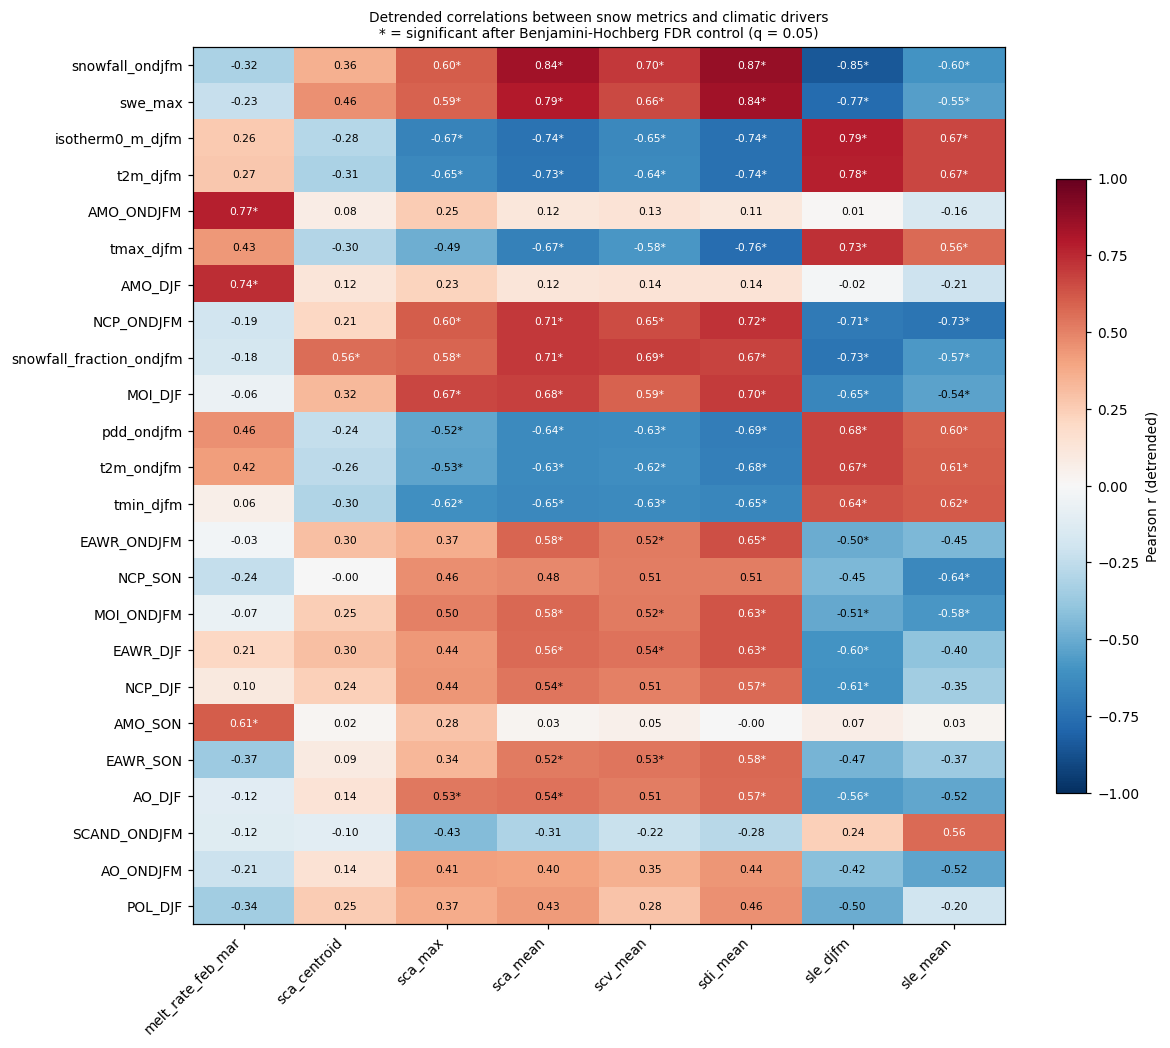

In [5]:
# ---- Figure: correlation heatmap, snow metrics x drivers (detrended)
piv = corr.pivot(index="driver", columns="snow", values="r_detrended")
sig = corr.pivot(index="driver", columns="snow", values="sig_detrended").fillna(False)
keep = piv.abs().max(axis=1).sort_values(ascending=False).head(24).index
piv, sig = piv.loc[keep], sig.loc[keep]

fig, ax = plt.subplots(figsize=(1.05 * len(piv.columns) + 3.5, 0.34 * len(piv) + 2.2))
im = ax.imshow(piv.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(piv.columns)), piv.columns, rotation=45, ha="right")
ax.set_yticks(range(len(piv.index)), piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.2f}" + ("*" if sig.values[i, j] else ""),
                    ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.55 else "black")
fig.colorbar(im, ax=ax, shrink=.7, label="Pearson r (detrended)")
ax.set_title("Detrended correlations between snow metrics and climatic drivers\n"
             "* = significant after Benjamini-Hochberg FDR control (q = 0.05)", fontsize=9)
fig.savefig(os.path.join(FIGDIR, "fig02_correlation_heatmap.png"), dpi=300)
plt.show()

## 4. Partial correlation - separating the dynamic from the thermodynamic pathway

A circulation index can correlate with snow simply because it also drives temperature and
precipitation. Holding `t2m_djfm` and `precip_ondjfm` fixed answers a sharper question:

> *does this circulation pattern still explain snow variability once the local thermodynamics
> are accounted for?*

A surviving partial correlation is evidence of a **direct dynamic control** (storm-track
positioning, blocking) - a genuinely mechanistic result, and the strongest thing a
correlation-based attribution can claim.

In [6]:
CTRL = [c for c in ["t2m_djfm", "precip_ondjfm"] if c in df.columns]
if len(CTRL) < 2:
    print("Climate predictors missing - run notebook 02 first. Skipping section 4.")
    pcorr = pd.DataFrame()
else:
    recs = []
    for sv in SNOW_VARS:
        for dv in IDX_VARS:
            r0, p0, n0 = corr_adj(df[sv], df[dv], "pearson")
            r1, p1, n1 = partial_corr(df[sv], df[dv], [df[c] for c in CTRL])
            recs.append(dict(snow=sv, index=dv, n=n1,
                             r_simple=r0, p_simple=p0,
                             r_partial=r1, p_partial=p1,
                             attenuation=(abs(r0) - abs(r1))))
    pcorr = pd.DataFrame(recs)
    rej, adj = bh_fdr(pcorr["p_partial"].values, q=0.05)
    pcorr["q_partial"], pcorr["sig_partial"] = adj, rej
    pcorr.to_csv(os.path.join(RESDIR, "table3_partial_correlations.csv"), index=False)
    print(f"controlled for: {CTRL}")
    print(f"{pcorr['sig_partial'].sum()} of {len(pcorr)} partial correlations survive FDR")
    display_cols = ["snow", "index", "n", "r_simple", "r_partial", "q_partial"]
    pcorr.reindex(pcorr.r_partial.abs().sort_values(ascending=False).index)[display_cols].head(20).round(3)

controlled for: ['t2m_djfm', 'precip_ondjfm']
0 of 288 partial correlations survive FDR


## 5. Multiple regression and variance partitioning

For each snow metric a model is fitted on standardised predictors:

$$ Z(\text{snow}) = \beta_T\, Z(T) + \beta_P\, Z(P) + \beta_C\, Z(\text{index}) + \varepsilon $$

Three diagnostics are reported:

- **VIF** - collinearity. VIF > 5 means the individual coefficients are not interpretable and
  you must report variance partitioning instead of raw betas.
- **LMG relative importance** (Lindeman-Merenda-Gold) - the increment in R2 contributed by each
  predictor, averaged over all orderings of entry. This is the defensible way to say
  *"temperature explains more than precipitation"* when the two are correlated.
- **Commonality split** - unique-to-T, unique-to-P and shared variance.

In [7]:
def zscore(a):
    a = np.asarray(a, float)
    return (a - np.nanmean(a)) / np.nanstd(a, ddof=1)


def ols(X, y):
    A = np.column_stack([np.ones(len(y)), X])
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    yhat = A @ beta
    ss_res = float(((y - yhat) ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    n, k = len(y), X.shape[1]
    adj = 1 - (1 - r2) * (n - 1) / (n - k - 1) if n > k + 1 else np.nan
    return beta, r2, adj


def vif(X):
    out = []
    for j in range(X.shape[1]):
        others = np.delete(X, j, axis=1)
        _, r2, _ = ols(others, X[:, j])
        out.append(1 / max(1e-9, 1 - r2))
    return out


def lmg(X, y, names):
    """Relative importance: mean sequential R2 increment over all predictor orderings."""
    k = X.shape[1]
    contrib = {n: [] for n in names}
    for order in itertools.permutations(range(k)):
        prev = 0.0
        for pos, j in enumerate(order):
            cols = list(order[:pos + 1])
            _, r2, _ = ols(X[:, cols], y)
            contrib[names[j]].append(r2 - prev)
            prev = r2
    return {n: float(np.mean(v)) for n, v in contrib.items()}


def fit_model(target, preds):
    sub = df[[target] + preds].dropna()
    if len(sub) < len(preds) + 6:
        return None
    y = zscore(sub[target].values)
    X = np.column_stack([zscore(sub[c].values) for c in preds])
    beta, r2, adj = ols(X, y)
    imp = lmg(X, y, preds)
    return dict(target=target, n=len(sub), r2=r2, adj_r2=adj,
                betas=dict(zip(preds, beta[1:])),
                vif=dict(zip(preds, vif(X))),
                lmg=imp)


PRED_SETS = {}
base = [c for c in ["t2m_djfm", "precip_ondjfm"] if c in df.columns]
if base:
    PRED_SETS["T+P"] = base
if "snowfall_fraction_ondjfm" in df.columns:
    PRED_SETS["T+P+snowfall fraction"] = base + ["snowfall_fraction_ondjfm"]

# add the single best circulation index (by |partial r|) as a third/fourth predictor
if len(pcorr):
    best_idx = (pcorr.groupby("index")["r_partial"].apply(lambda s: s.abs().max())
                     .sort_values(ascending=False).index[0])
    PRED_SETS[f"T+P+{best_idx}"] = base + [best_idx]
    print("best circulation index by |partial r|:", best_idx)

model_rows = []
for tag, preds in PRED_SETS.items():
    for target in SNOW_VARS:
        m = fit_model(target, preds)
        if not m:
            continue
        row = dict(model=tag, target=target, n=m["n"], r2=m["r2"], adj_r2=m["adj_r2"])
        for p in preds:
            row[f"beta_{p}"] = m["betas"][p]
            row[f"vif_{p}"]  = m["vif"][p]
            row[f"lmg_{p}"]  = m["lmg"][p]
        model_rows.append(row)

models = pd.DataFrame(model_rows)
models.to_csv(os.path.join(RESDIR, "table4_regression_models.csv"), index=False)
models.round(3).head(20)

best circulation index by |partial r|: AMO_DJF


,model,target,n,r2,adj_r2,beta_t2m_djfm,vif_t2m_djfm,lmg_t2m_djfm,beta_precip_ondjfm,vif_precip_ondjfm,lmg_precip_ondjfm,beta_snowfall_fraction_ondjfm,vif_snowfall_fraction_ondjfm,lmg_snowfall_fraction_ondjfm,beta_AMO_DJF,vif_AMO_DJF,lmg_AMO_DJF
0,T+P,sca_mean,24,0.664,0.631,-0.810,1.019,0.622,0.253,1.019,0.041,NaN,NaN,NaN,NaN,NaN,NaN
1,T+P,sca_max,24,0.480,0.430,-0.698,1.019,0.469,0.140,1.019,0.011,NaN,NaN,NaN,NaN,NaN,NaN
2,T+P,sle_mean,24,0.536,0.491,0.738,1.019,0.526,-0.137,1.019,0.010,NaN,NaN,NaN,NaN,NaN,NaN
3,T+P,sle_djfm,24,0.732,0.706,0.850,1.019,0.684,-0.271,1.019,0.048,NaN,NaN,NaN,NaN,NaN,NaN
4,T+P,sdi_mean,24,0.722,0.696,-0.828,1.019,0.643,0.335,1.019,0.079,NaN,NaN,NaN,NaN,NaN,NaN
5,T+P,scv_mean,24,0.498,0.450,-0.712,1.019,0.493,0.103,1.019,0.005,NaN,NaN,NaN,NaN,NaN,NaN
6,T+P,sca_centroid,24,0.069,-0.020,-0.222,1.019,0.053,-0.112,1.019,0.016,NaN,NaN,NaN,NaN,NaN,NaN
7,T+P,melt_rate_feb_mar,24,0.132,0.049,0.229,1.019,0.043,-0.315,1.019,0.089,NaN,NaN,NaN,NaN,NaN,NaN
8,T+P+snowfall fraction,sca_mean,24,0.777,0.743,-0.275,3.556,0.325,0.394,1.194,0.089,0.663,3.895,0.363,NaN,NaN,NaN
9,T+P+snowfall fraction,sca_max,24,0.505,0.431,-0.443,3.556,0.266,0.207,1.194,0.027,0.316,3.895,0.213,NaN,NaN,NaN


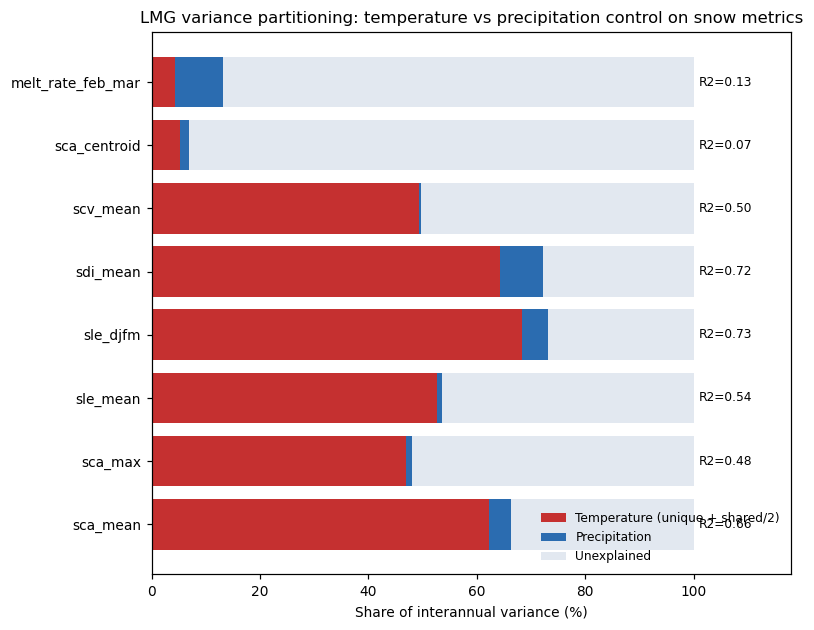

In [8]:
# ---- Figure: variance partitioning between temperature and precipitation
if base and len(models):
    sub = models[models.model == "T+P"].set_index("target")
    tcol, pcol = f"lmg_{base[0]}", f"lmg_{base[1]}"
    sub = sub.reindex([v for v in SNOW_VARS if v in sub.index])

    fig, ax = plt.subplots(figsize=(7.5, 0.55 * len(sub) + 2))
    ypos = np.arange(len(sub))
    ax.barh(ypos, sub[tcol] * 100, color="#c53030", label="Temperature (unique + shared/2)")
    ax.barh(ypos, sub[pcol] * 100, left=sub[tcol] * 100, color="#2b6cb0",
            label="Precipitation")
    resid = (1 - sub["r2"]) * 100
    ax.barh(ypos, resid, left=(sub[tcol] + sub[pcol]) * 100, color="#e2e8f0",
            label="Unexplained")
    for i, (t, p, r) in enumerate(zip(sub[tcol], sub[pcol], sub["r2"])):
        ax.text(101, i, f"R2={r:.2f}", va="center", fontsize=8)
    ax.set_yticks(ypos, sub.index)
    ax.set_xlabel("Share of interannual variance (%)")
    ax.set_xlim(0, 118)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    ax.set_title("LMG variance partitioning: temperature vs precipitation control on snow metrics")
    fig.savefig(os.path.join(FIGDIR, "fig03_variance_partitioning.png"), dpi=300)
    plt.show()

## 6. Sensitivity coefficients and trend decomposition

**This is the section that turns correlation into attribution.** Fit the snow metric in
*physical* units against temperature and precipitation:

$$ S = a + \frac{\partial S}{\partial T}\,T + \frac{\partial S}{\partial P}\,P $$

then attribute the observed snow trend to the observed driver trends:

$$ \underbrace{\frac{dS}{dt}}_{\text{observed}} \approx
   \frac{\partial S}{\partial T}\frac{dT}{dt} +
   \frac{\partial S}{\partial P}\frac{dP}{dt} + \text{residual} $$

The residual absorbs everything the two predictors miss (circulation, sensor drift, model
error) and should be reported honestly, not hidden.

Sentences you will be able to write from `table5`:

> *Snow cover area declines by **X km2 per degree C** of winter warming and increases by
> **Y km2 per 10 mm** of seasonal precipitation. Over 2000/01-2023/24 winter temperature rose
> **dT** and precipitation changed **dP**, which together account for **Z%** of the observed
> SCA decline; **R%** remains unexplained.*

In [9]:
def decompose(target, tvar="t2m_djfm", pvar="precip_ondjfm"):
    sub = df[["season", target, tvar, pvar]].dropna()
    if len(sub) < 10:
        return None
    y  = sub[target].values
    X  = sub[[tvar, pvar]].values
    beta, r2, adj = ols(X, y)
    dS_dT, dS_dP = beta[1], beta[2]

    yrs = sub["season"].values
    tr  = lambda a: sens_slope(a, yrs)[0]        # Theil-Sen, robust
    dT, dP, dS = tr(sub[tvar].values), tr(sub[pvar].values), tr(y)
    n_yr = yrs.max() - yrs.min()

    contrib_T = dS_dT * dT
    contrib_P = dS_dP * dP
    expl      = contrib_T + contrib_P
    return dict(
        target=target, n=len(sub), model_r2=r2, model_adj_r2=adj,
        dS_dT=dS_dT, dS_dP_per_10mm=dS_dP * 10,
        trend_T_per_yr=dT, trend_P_per_yr=dP, trend_S_obs_per_yr=dS,
        total_change_T=dT * n_yr, total_change_P=dP * n_yr, total_change_S=dS * n_yr,
        attributed_to_T=contrib_T, attributed_to_P=contrib_P,
        attributed_total=expl, residual=dS - expl,
        pct_explained=100 * expl / dS if dS != 0 else np.nan,
        pct_from_T=100 * contrib_T / dS if dS != 0 else np.nan,
        pct_from_P=100 * contrib_P / dS if dS != 0 else np.nan,
    )


if base:
    dec = pd.DataFrame([d for d in (decompose(v) for v in SNOW_VARS) if d])
    dec.to_csv(os.path.join(RESDIR, "table5_trend_decomposition.csv"), index=False)
    print("Sensitivities and trend attribution (Theil-Sen trends, OLS sensitivities)\n")
    print(dec[["target", "dS_dT", "dS_dP_per_10mm", "trend_S_obs_per_yr",
               "pct_from_T", "pct_from_P", "pct_explained"]].round(3).to_string(index=False))
else:
    dec = pd.DataFrame()
    print("Run notebook 02 first - climate predictors are required for this section.")

Sensitivities and trend attribution (Theil-Sen trends, OLS sensitivities)

           target     dS_dT  dS_dP_per_10mm  trend_S_obs_per_yr  pct_from_T  pct_from_P  pct_explained
         sca_mean  -821.930          16.732             -77.274      70.321       1.393         71.714
          sca_max -2158.397          28.167            -183.661      77.695       0.987         78.682
         sle_mean    97.459          -1.180               8.303      77.601       0.914         78.516
         sle_djfm   101.016          -2.100               8.839      75.555       1.529         77.085
         sdi_mean    -1.782           0.047              -0.184      64.166       1.645         65.811
         scv_mean    -0.966           0.009              -0.121      52.671       0.484         53.155
     sca_centroid    -0.046          -0.002               0.006     -54.823       1.753        -53.069
melt_rate_feb_mar     0.048          -0.004              -0.006     -55.748      -4.859        -60.60

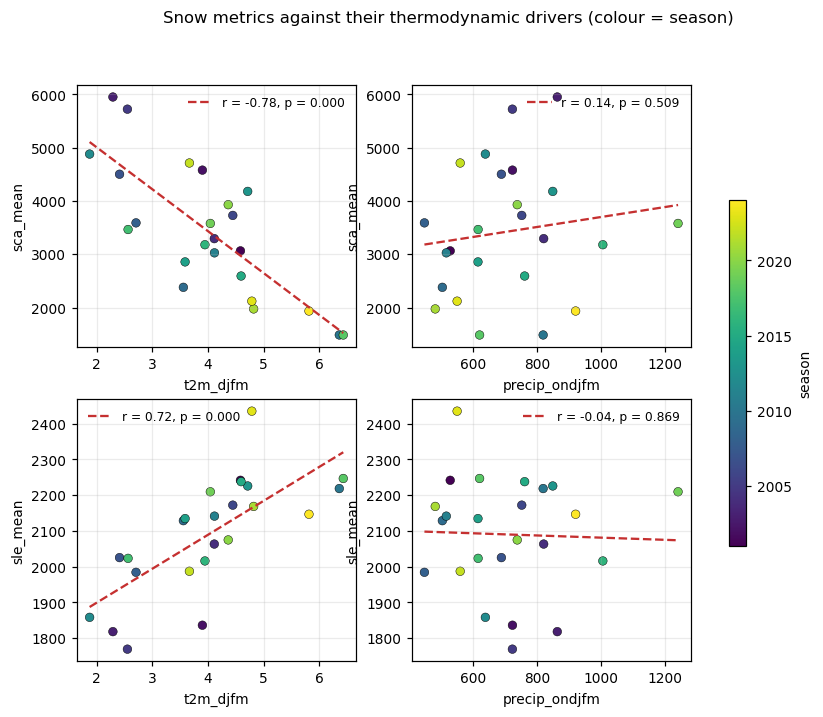

In [10]:
# ---- Figure: snow metric vs its two drivers, with the fitted sensitivity
if base and len(dec):
    targets = [v for v in ["sca_mean", "sle_mean"] if v in df.columns]
    fig, axes = plt.subplots(len(targets), 2, figsize=(9, 3.4 * len(targets)))
    axes = np.atleast_2d(axes)
    for i, tv in enumerate(targets):
        for j, dv in enumerate(base):
            ax = axes[i, j]
            s = df[[tv, dv, "season"]].dropna()
            sc = ax.scatter(s[dv], s[tv], c=s["season"], cmap="viridis", s=32,
                            edgecolor="k", linewidth=.3)
            b, a = np.polyfit(s[dv], s[tv], 1)
            xs = np.linspace(s[dv].min(), s[dv].max(), 50)
            r, p, _ = corr_adj(s[tv], s[dv])
            ax.plot(xs, a + b * xs, "--", color="#c53030",
                    label=f"r = {r:.2f}, p = {p:.3f}")
            ax.set_xlabel(dv); ax.set_ylabel(tv)
            ax.legend(frameon=False, fontsize=8); ax.grid(alpha=.25)
    fig.colorbar(sc, ax=axes, shrink=.6, label="season")
    fig.suptitle("Snow metrics against their thermodynamic drivers (colour = season)")
    fig.savefig(os.path.join(FIGDIR, "fig04_driver_scatter.png"), dpi=300)
    plt.show()

## 7. Auto-generated summary for the response letter

Writes `results/attribution_summary.md` with the numbers already formatted. Read it, sanity-check
every figure against the tables, then adapt the wording - do not paste it unedited.

In [11]:
lines = ["# Attribution analysis - auto-generated summary", "",
         f"Seasons: {int(df.season.min())}-{int(df.season.max())} (n = {len(df)})", ""]

lines += ["## 1. Trends and change points", ""]
for _, r in trend_tbl.iterrows():
    lines.append(f"- **{r['variable']}**: Sen's slope {r['sens_slope_per_yr']:+.4f}/yr "
                 f"(tau = {r['kendall_tau']:+.2f}, p = {r['mk_p']:.3f}); "
                 f"Pettitt change point at season {r['change_point_season']} "
                 f"(p = {r['pettitt_p']:.3f}), mean shift {r['mean_shift_pct']:+.1f}%")

lines += ["", "## 2. Strongest detrended correlations surviving FDR (q = 0.05)", ""]
top = corr[corr.sig_detrended].reindex(
    corr[corr.sig_detrended].r_detrended.abs().sort_values(ascending=False).index).head(15)
if len(top):
    for _, r in top.iterrows():
        lines.append(f"- {r.snow} vs {r.driver}: r = {r.r_detrended:+.2f} "
                     f"(q = {r.q_detrended:.3f}, n = {int(r.n)}, {r.family})")
else:
    lines.append("- none survived FDR control; report this honestly and lean on the "
                 "regression and decomposition results instead")

if len(pcorr):
    lines += ["", f"## 3. Circulation indices surviving control for {CTRL}", ""]
    tp = pcorr[pcorr.sig_partial].reindex(
        pcorr[pcorr.sig_partial].r_partial.abs().sort_values(ascending=False).index).head(10)
    for _, r in tp.iterrows():
        lines.append(f"- {r.snow} vs {r['index']}: simple r = {r.r_simple:+.2f} -> "
                     f"partial r = {r.r_partial:+.2f} (q = {r.q_partial:.3f})")
    if not len(tp):
        lines.append("- no circulation index retains a significant partial correlation; "
                     "the thermodynamic pathway dominates")

if len(dec):
    lines += ["", "## 4. Sensitivity and trend attribution", ""]
    for _, r in dec.iterrows():
        lines.append(
            f"- **{r.target}**: dS/dT = {r.dS_dT:+.2f} per degC, "
            f"dS/dP = {r.dS_dP_per_10mm:+.2f} per 10 mm; observed trend "
            f"{r.trend_S_obs_per_yr:+.3f}/yr, of which {r.pct_from_T:+.0f}% from temperature "
            f"and {r.pct_from_P:+.0f}% from precipitation "
            f"({r.pct_explained:.0f}% explained, model R2 = {r.model_r2:.2f})")

lines += ["", "## 5. Caveats to state in the manuscript", "",
          "- n = 24 seasons: limited power; effective sample size is smaller still where "
          "series are autocorrelated.",
          "- ERA5-Land is a reanalysis; temperature and precipitation over complex terrain "
          "carry their own uncertainty.",
          "- This is attribution to proximate climatic drivers, not formal anthropogenic "
          "detection and attribution.",
          "- Correlation with a circulation index is consistent with, but does not prove, "
          "a causal dynamic pathway."]

out = os.path.join(RESDIR, "attribution_summary.md")
with open(out, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
print("\n".join(lines))
print("\n\nsaved:", out)

# Attribution analysis - auto-generated summary

Seasons: 2001-2024 (n = 24)

## 1. Trends and change points

- **sca_mean**: Sen's slope -77.2741/yr (tau = -0.29, p = 0.049); Pettitt change point at season 2008 (p = 0.159), mean shift -30.6%
- **sca_max**: Sen's slope -183.6609/yr (tau = -0.21, p = 0.159); Pettitt change point at season 2008 (p = 0.326), mean shift -25.8%
- **sle_mean**: Sen's slope +8.3030/yr (tau = +0.25, p = 0.097); Pettitt change point at season 2012 (p = 0.363), mean shift +6.8%
- **sle_djfm**: Sen's slope +8.8391/yr (tau = +0.28, p = 0.062); Pettitt change point at season 2008 (p = 0.260), mean shift +8.2%
- **sdi_mean**: Sen's slope -0.1836/yr (tau = -0.29, p = 0.049); Pettitt change point at season 2007 (p = 0.085), mean shift -31.7%
- **scv_mean**: Sen's slope -0.1213/yr (tau = -0.35, p = 0.017); Pettitt change point at season 2007 (p = 0.085), mean shift -31.1%
- **sca_centroid**: Sen's slope +0.0056/yr (tau = +0.12, p = 0.446); Pettitt change point at seaso

---

## What to add to the manuscript

**Methods, new subsection 2.x "Attribution of snow-cover trends"** - describe the ERA5-Land
predictors, the circulation indices and their sources, the detrending and FDR procedure, the
effective-sample-size adjustment, LMG variance partitioning, and the trend decomposition.

**Results, new subsection** - Table 1 (trends + Pettitt change points), Table 2 (correlation
matrix), Table 3 (partial correlations), Table 5 (sensitivities and attribution), Figures 2-4.

**Discussion** - the elevation-dependent story if you extend this by elevation band, the
comparison with Zagros/Iran/Turkey studies the reviewer also asked for, and the caveats in
section 5 of the summary above.

**Data availability** - point to this the repository folder; the reviewer explicitly asked
whether code is available.